Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_27432\4206580988.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='viridis')


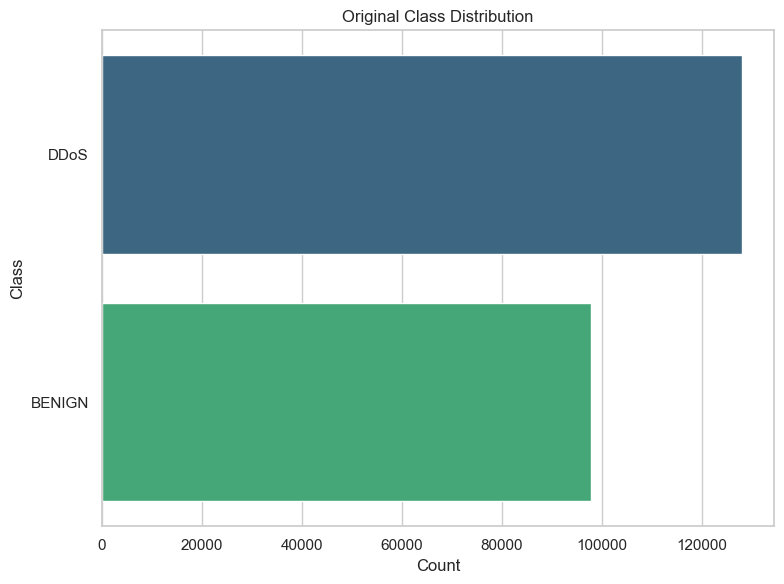

Missing before drop: 4
Missing after drop: 0
Duplicates before drop: 2633
Duplicates after drop: 0


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_27432\4206580988.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])


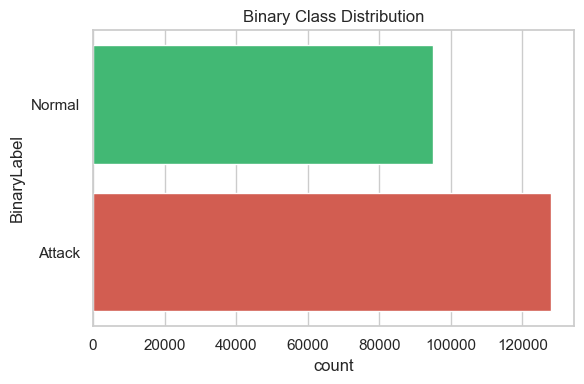

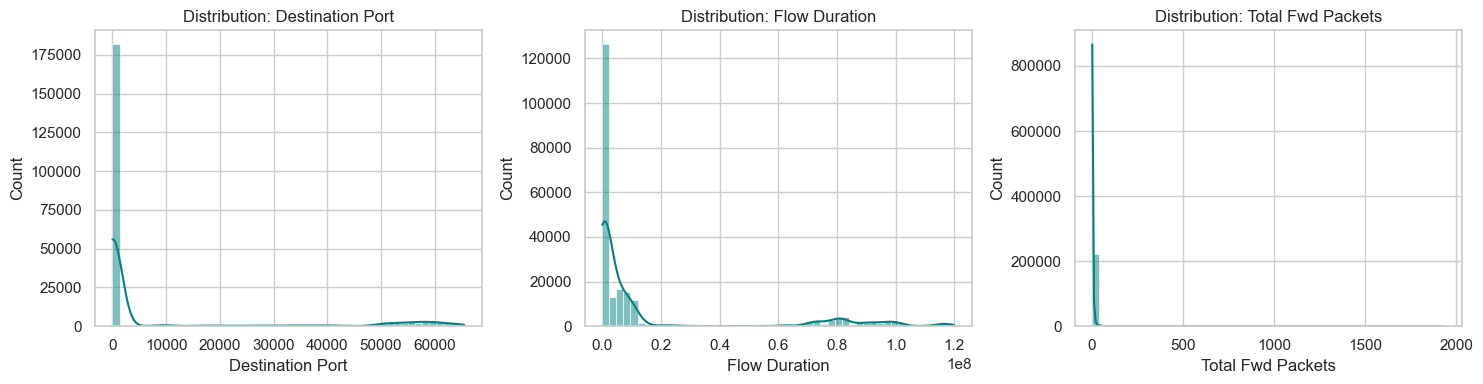

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_27432\4206580988.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y_balanced, palette=["#2ecc71", "#e74c3c"])


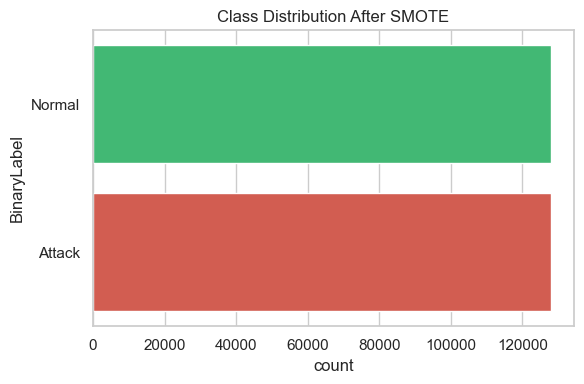


Training Logistic Regression...
Training Accuracy: 0.9883
Testing Accuracy: 0.9883
Classification Report (Test):
              precision    recall  f1-score   support

      Attack     0.9776    0.9996    0.9885     38405
      Normal     0.9996    0.9771    0.9882     38405

    accuracy                         0.9883     76810
   macro avg     0.9886    0.9883    0.9883     76810
weighted avg     0.9886    0.9883    0.9883     76810


Training Decision Tree...
Training Accuracy: 1.0000
Testing Accuracy: 0.9998
Classification Report (Test):
              precision    recall  f1-score   support

      Attack     0.9998    0.9999    0.9998     38405
      Normal     0.9999    0.9998    0.9998     38405

    accuracy                         0.9998     76810
   macro avg     0.9998    0.9998    0.9998     76810
weighted avg     0.9998    0.9998    0.9998     76810


Training Random Forest...
Training Accuracy: 1.0000
Testing Accuracy: 0.9999
Classification Report (Test):
              pr

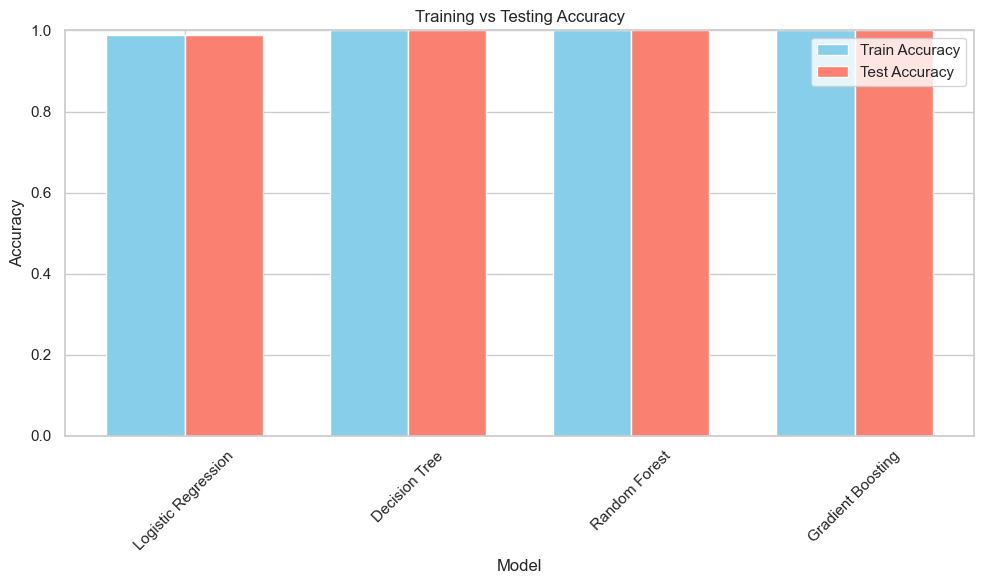

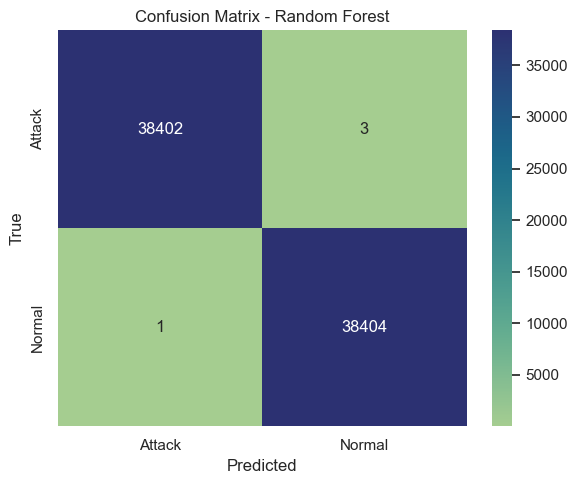

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import numpy as np

sns.set(style='whitegrid')

# Step 1: Load dataset
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Auto detect label column
df.columns = df.columns.str.strip()
possible_labels = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in possible_labels:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found in dataset.")

# Step 2: Visualize original class distribution
plt.figure(figsize=(8,6))
sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='viridis')
plt.title('Original Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

# Step 3: Handle missing values and duplicates
print(f"Missing before drop: {df.isnull().sum().sum()}")
df.dropna(inplace=True)
print(f"Missing after drop: {df.isnull().sum().sum()}")

print(f"Duplicates before drop: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after drop: {df.duplicated().sum()}")

# Step 4: Create binary labels
df['BinaryLabel'] = df[label_col].apply(lambda x: 'Normal' if str(x).upper() == 'BENIGN' else 'Attack')

plt.figure(figsize=(6,4))
sns.countplot(df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])
plt.title('Binary Class Distribution')
plt.tight_layout()
plt.show()

# Step 5: Prepare features and target
X = df.drop(columns=[label_col, 'BinaryLabel'])
y = df['BinaryLabel']

# Step 6: Identify categorical and numeric features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Step 7: Visualize few numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_features[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True, color='teal')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

# Step 8: Visualize categorical example feature if exists
if categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=categorical_features[0], data=X, palette='pastel')
    plt.title(f'{categorical_features[0]} Distribution')
    plt.tight_layout()
    plt.show()

# Step 9: Clean numeric data - crucial to fix your ValueError
import numpy as np

# Replace infinite by NaN and fill with zero
X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan)
X[numeric_features] = X[numeric_features].fillna(0)

# Optionally clip extremes (adjust bounds if needed)
X[numeric_features] = X[numeric_features].clip(lower=-1e10, upper=1e10)

# Step 10: Build preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])
X_processed = preprocessor.fit_transform(X)

# Step 11: Balance data with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_processed, y)

plt.figure(figsize=(6,4))
sns.countplot(y_balanced, palette=["#2ecc71", "#e74c3c"])
plt.title('Class Distribution After SMOTE')
plt.tight_layout()
plt.show()

# Step 12: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced)

# Step 13: Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

train_acc = {}
test_acc = {}

# Step 14: Training and evaluation on train/test
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc[name] = accuracy_score(y_train, train_pred)
    test_acc[name] = accuracy_score(y_test, test_pred)
    print(f"Training Accuracy: {train_acc[name]:.4f}")
    print(f"Testing Accuracy: {test_acc[name]:.4f}")
    print(f"Classification Report (Test):\n{classification_report(y_test, test_pred, digits=4)}")

# Step 15: Accuracy comparison plot
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, [train_acc[l] for l in labels], width, label='Train Accuracy', color='skyblue')
ax.bar(x + width/2, [test_acc[l] for l in labels], width, label='Test Accuracy', color='salmon')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Step 16: Confusion matrix of best model (Random Forest)
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


Binary Classification pipeline

Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_27432\4210506437.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='viridis')


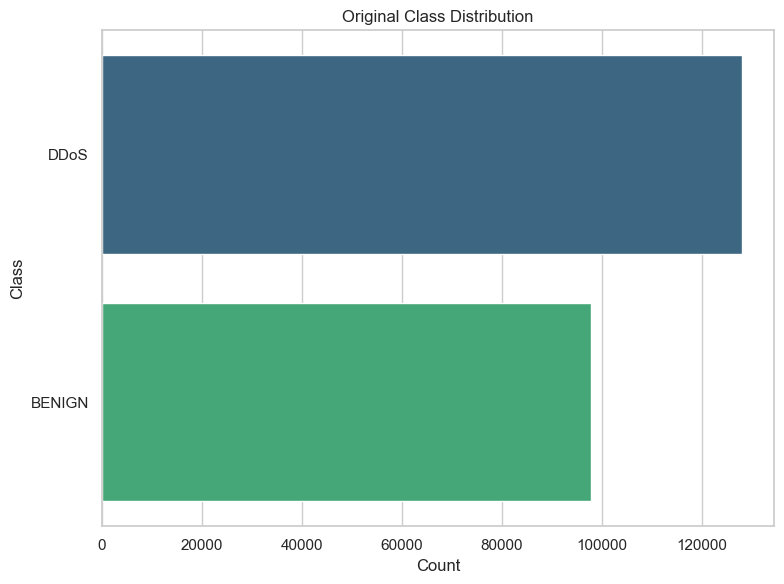

Missing before drop: 4
Missing after drop: 0
Duplicates before drop: 2633
Duplicates after drop: 0


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_27432\4210506437.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])


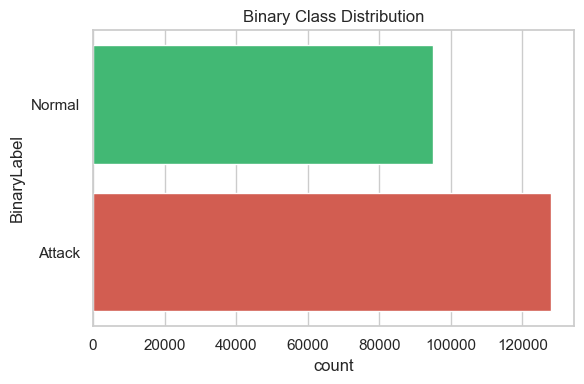

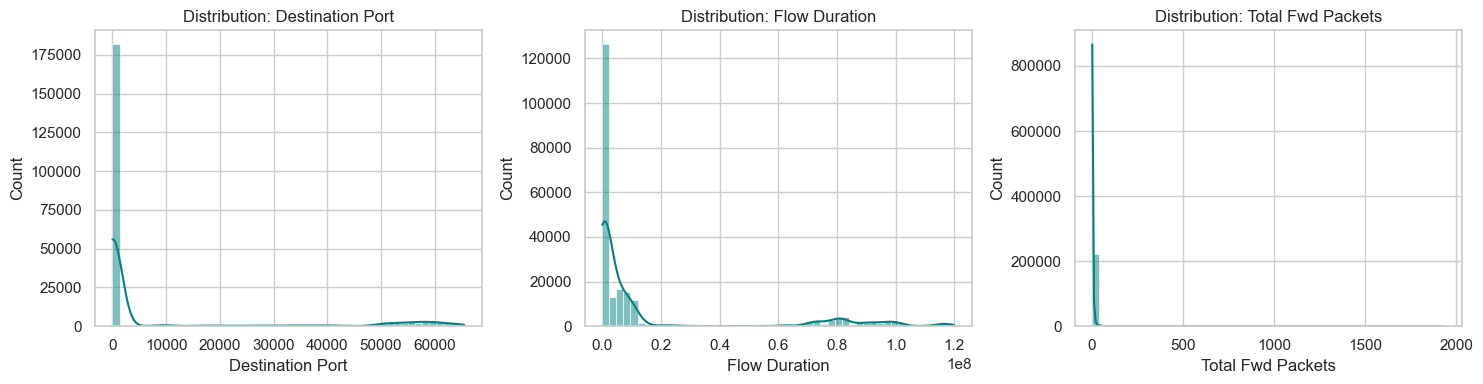

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_27432\4210506437.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y_balanced, palette=["#2ecc71", "#e74c3c"])


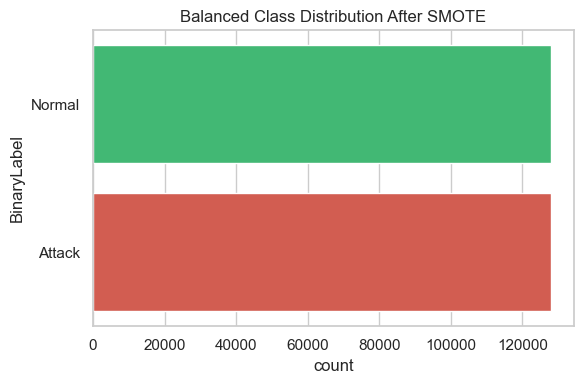


Training Logistic Regression...
Training accuracy: 0.9883
Testing accuracy: 0.9883
Test Classification Report:
              precision    recall  f1-score   support

      Attack     0.9776    0.9996    0.9885     38405
      Normal     0.9996    0.9771    0.9882     38405

    accuracy                         0.9883     76810
   macro avg     0.9886    0.9883    0.9883     76810
weighted avg     0.9886    0.9883    0.9883     76810


Training Decision Tree...
Training accuracy: 1.0000
Testing accuracy: 0.9998
Test Classification Report:
              precision    recall  f1-score   support

      Attack     0.9998    0.9999    0.9998     38405
      Normal     0.9999    0.9998    0.9998     38405

    accuracy                         0.9998     76810
   macro avg     0.9998    0.9998    0.9998     76810
weighted avg     0.9998    0.9998    0.9998     76810


Training Random Forest...
Training accuracy: 1.0000
Testing accuracy: 0.9999
Test Classification Report:
              precisio

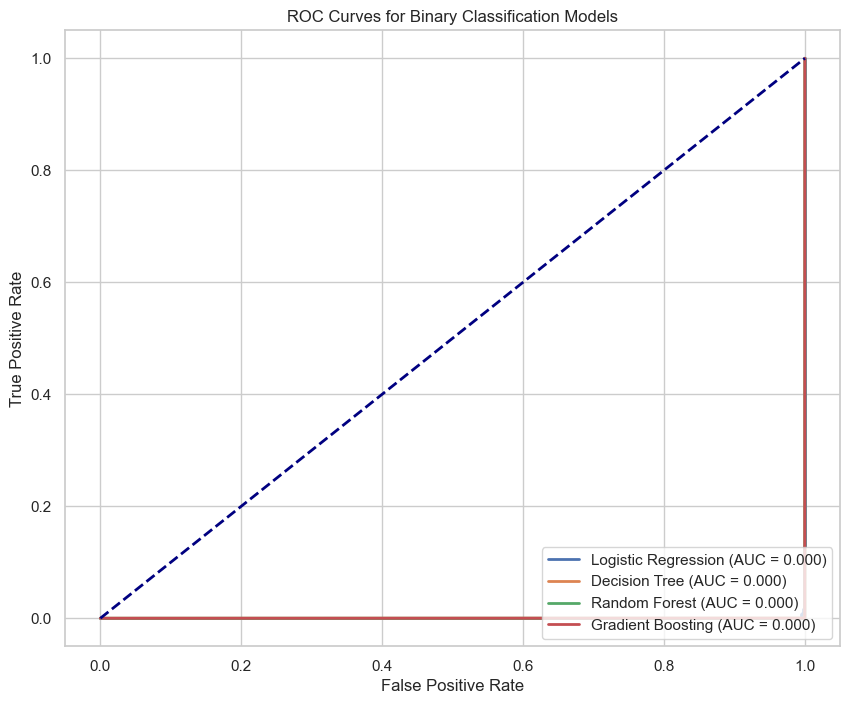

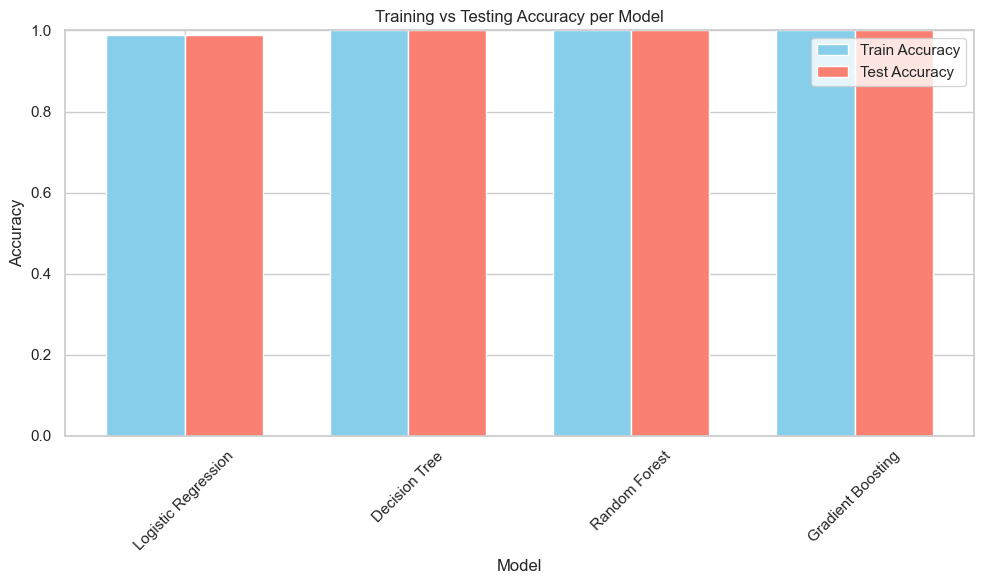

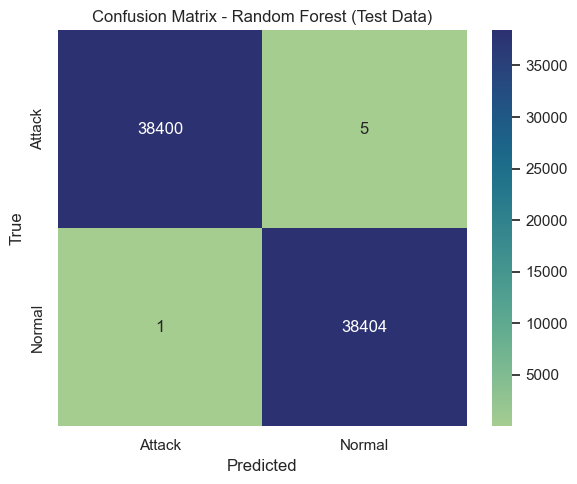

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

sns.set(style='whitegrid')

# Step 1: Load dataset
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Step 2: Detect label column dynamically and strip whitespace
df.columns = df.columns.str.strip()
label_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = next((col for col in label_candidates if col in df.columns), None)
if label_col is None:
    raise KeyError("Label column not found in dataset.")
print(f"Using label column: {label_col}")

# Step 3: Visualize original class distribution
plt.figure(figsize=(8,6))
sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='viridis')
plt.title('Original Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

# Step 4: Handle missing and duplicates
print(f"Missing before drop: {df.isnull().sum().sum()}")
df.dropna(inplace=True)
print(f"Missing after drop: {df.isnull().sum().sum()}")
print(f"Duplicates before drop: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after drop: {df.duplicated().sum()}")

# Step 5: Create binary labels
df['BinaryLabel'] = df[label_col].apply(lambda x: 'Normal' if str(x).upper() == 'BENIGN' else 'Attack')

plt.figure(figsize=(6,4))
sns.countplot(df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])
plt.title('Binary Class Distribution')
plt.tight_layout()
plt.show()

# Step 6: Prepare features and target
X = df.drop(columns=[label_col, 'BinaryLabel'])
y = df['BinaryLabel']

# Step 7: Identify categorical and numeric features
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

# Step 8: Visualize numeric distributions
plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_features[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True, color='teal')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

# Step 9: Visualize categorical if present
if categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=categorical_features[0], data=X, palette='pastel')
    plt.title(f'{categorical_features[0]} Distribution')
    plt.tight_layout()
    plt.show()

# Step 10: Clean numeric columns
X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan)
X[numeric_features] = X[numeric_features].fillna(0)
X[numeric_features] = X[numeric_features].clip(lower=-1e10, upper=1e10)

# Step 11: Build preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])
X_processed = preprocessor.fit_transform(X)

# Step 12: Balance dataset via SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_processed, y)

plt.figure(figsize=(6,4))
sns.countplot(y_balanced, palette=["#2ecc71", "#e74c3c"])
plt.title('Balanced Class Distribution After SMOTE')
plt.tight_layout()
plt.show()

# Step 13: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced)

# Step 14: Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

train_acc = {}
test_acc = {}

# Binarize class labels for ROC
y_train_bin = (y_train == 'Attack').astype(int)
y_test_bin = (y_test == 'Attack').astype(int)

# Step 15: Train models, evaluate with classification report and ROC
plt.figure(figsize=(10,8))
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc[name] = accuracy_score(y_train, train_pred)
    test_acc[name] = accuracy_score(y_test, test_pred)
    print(f"Training accuracy: {train_acc[name]:.4f}")
    print(f"Testing accuracy: {test_acc[name]:.4f}")
    print(f"Test Classification Report:\n{classification_report(y_test, test_pred, digits=4)}")

    # ROC curve
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Random guess line
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Binary Classification Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Step 16: Plot train vs test accuracy comparison
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, [train_acc[m] for m in labels], width, label='Train Accuracy', color='skyblue')
ax.bar(x + width/2, [test_acc[m] for m in labels], width, label='Test Accuracy', color='salmon')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy per Model')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Step 17: Confusion matrix for Random Forest test predictions
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix - Random Forest (Test Data)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()



Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Summary Table:

              Model  Sensitivity  Specificity  Precision  F1-Score AUC Train Acc Val Acc Test Acc  Train Time (s)
Logistic Regression       0.9875       0.9875     0.9906    0.9890   -    98.90%  98.78%   98.92%            1.28
      Decision Tree       1.0000       1.0000     0.9999    1.0000   -   100.00%  99.98%  100.00%            2.05
      Random Forest       0.9999       0.9999     0.9999    0.9999   -   100.00%  99.98%   99.99%           20.55
  Gradient Boosting       0.9998       0.9998     0.9998    0.9998   -    99.99%  99.98%   99.98%          128.41


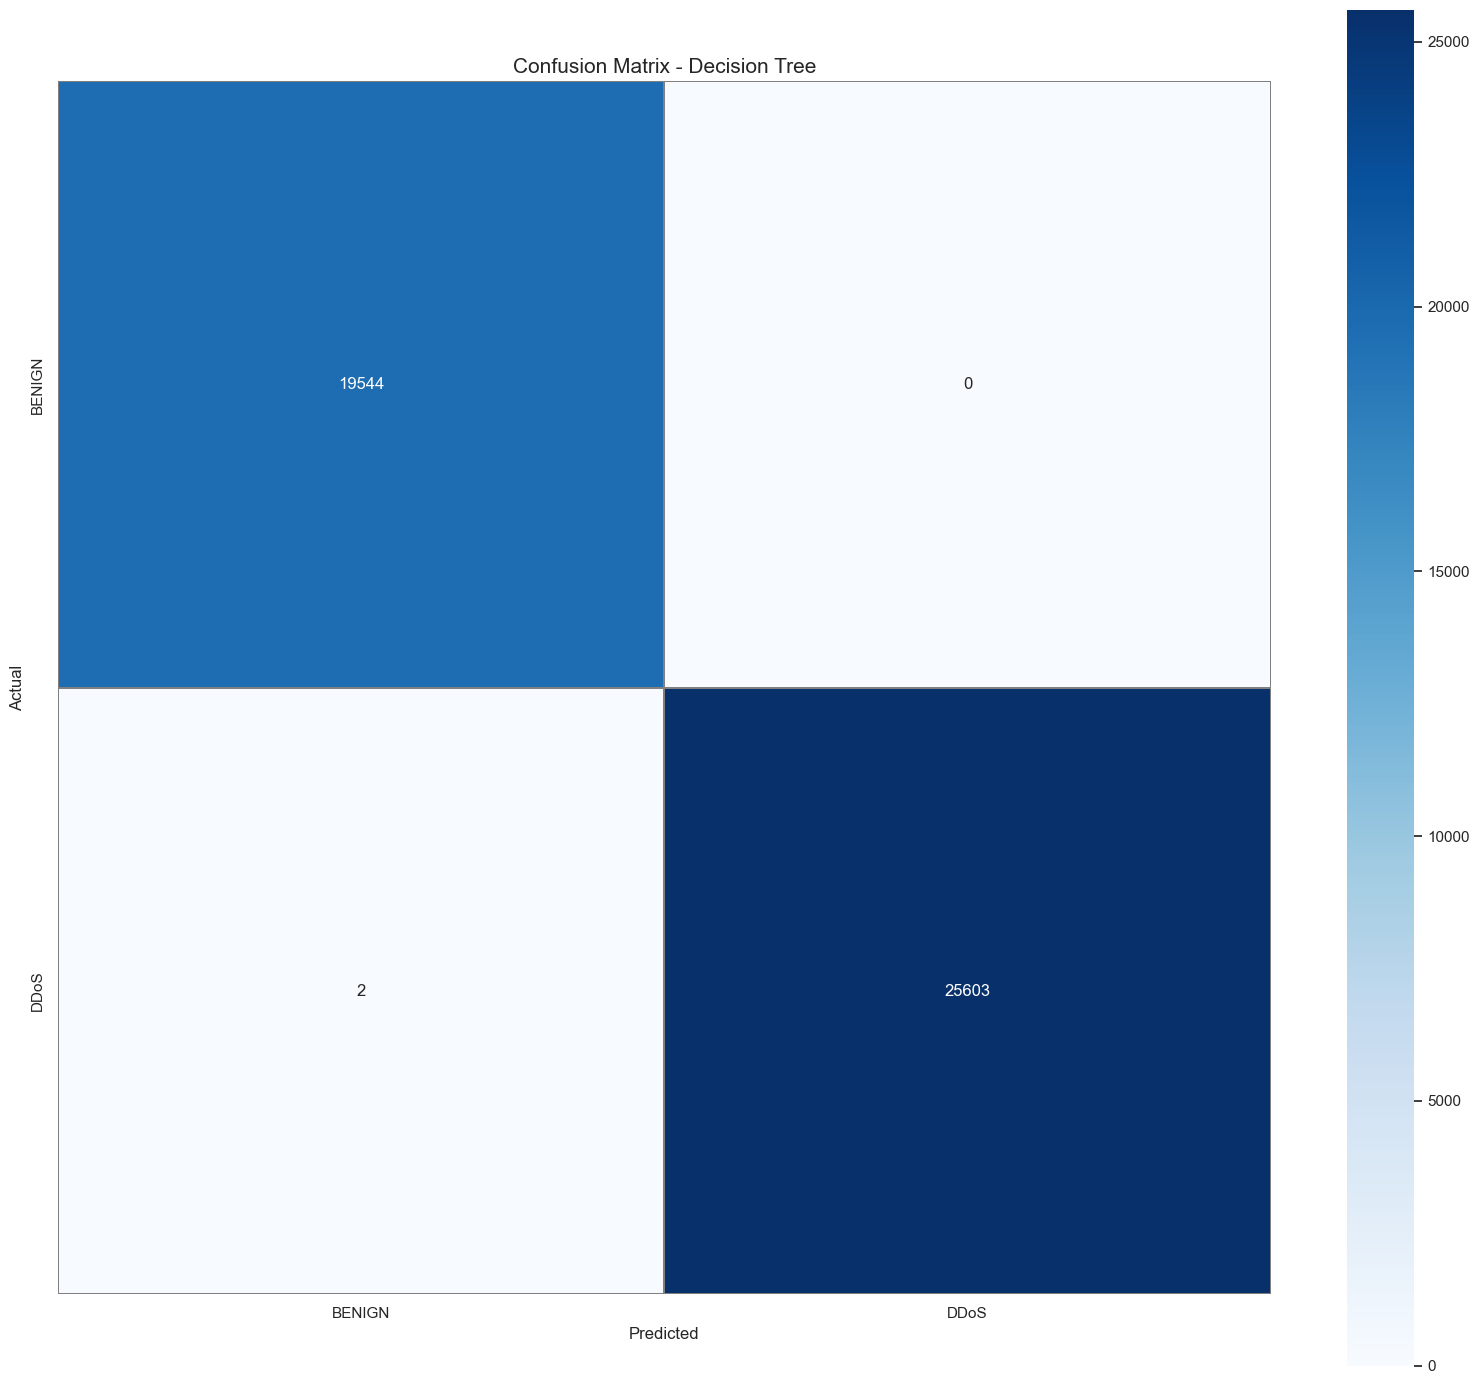

In [7]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid')

# Load dataset
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

label_col = 'Label'
df[label_col] = df[label_col].astype(str).str.strip()

X = df.drop([label_col], axis=1)
y = df[label_col]

# Identify categorical and numeric columns
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Convert numeric columns to numeric type, handle errors
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Replace infinite values with NaN and fill NaNs with 0
X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan).fillna(0)

# Split dataset: train (60%), val (20%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Preprocessing pipeline for numeric scaling and categorical encoding
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=300, multi_class='auto', solver='lbfgs'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

def macro_specificity(cm):
    specs = []
    for i in range(cm.shape[0]):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(cm, i, axis=0)[:, i])
        spec = tn / (tn + fp) if (tn + fp) else 0
        specs.append(spec)
    return np.mean(specs)

results = []
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time

    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)
    test_pred = model.predict(X_test_processed)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    sensitivity = recall_score(y_test, test_pred, average='macro', zero_division=0)
    precision = precision_score(y_test, test_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, test_pred, average='macro', zero_division=0)

    try:
        y_score = model.predict_proba(X_test_processed)
        auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    except Exception:
        auc = np.nan

    cm = confusion_matrix(y_test, test_pred, labels=classes)
    specificity = macro_specificity(cm)

    results.append({
        'Model': name,
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'Precision': round(precision, 4),
        'F1-Score': round(f1, 4),
        'AUC': round(auc, 4) if not np.isnan(auc) else '-',
        'Train Acc': f"{train_acc*100:.2f}%",
        'Val Acc': f"{val_acc*100:.2f}%",
        'Test Acc': f"{test_acc*100:.2f}%",
        'Train Time (s)': round(train_time, 2)
    })

# Summary table
results_df = pd.DataFrame(results)
print("\nSummary Table:\n")
print(results_df.to_string(index=False))

# Plot confusion matrix for best model based on test accuracy
best_model_index = max(range(len(results)), key=lambda i: float(results[i]['Test Acc'].strip('%')))
best_model_name = results[best_model_index]['Model']
best_model = models[best_model_name]
best_pred = best_model.predict(X_test_processed)

plt.figure(figsize=(16, 14))
cm_best = confusion_matrix(y_test, best_pred, labels=classes)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, square=True,
            cbar=True, linewidths=0.2, linecolor='gray')
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=15)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()
